# U-Net Segmentation — E-Waste PCB Components

**Dataset:** `U-NET-segmentation-.v3i.coco/` (COCO polygon format)  
**Classes:** board, capacitor, chip, knob (+ background)  
**Model:** U-Net with ResNet-34 encoder pretrained on ImageNet  

**Folder assumption:** this notebook sits in the same folder as `U-NET-segmentation-.v3i.coco/`
```
your_folder/
├── unet_ewaste.ipynb       ← this file
└── U-NET-segmentation-.v3i.coco/
    ├── train/
    │   ├── *.jpg
    │   └── _annotations.coco.json
    ├── valid/
    │   ├── *.jpg
    │   └── _annotations.coco.json
    └── test/
        ├── *.jpg
        └── _annotations.coco.json
```

## 1. Install dependencies

## 2. Imports

In [1]:
import os
import json
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from pycocotools.coco import COCO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

/home/alien/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Using device: cuda


## 3. Paths — notebook sits next to the dataset folder

In [2]:
# Notebook is in the same folder as U-NET-segmentation-.v3i.coco/
# Path() with no argument = current working directory = folder where notebook lives
DATASET_DIR = Path('U-NET-segmentation-.v3i.coco')

TRAIN_DIR = DATASET_DIR / 'train'
VALID_DIR = DATASET_DIR / 'valid'
TEST_DIR  = DATASET_DIR / 'test'

TRAIN_JSON = TRAIN_DIR / '_annotations.coco.json'
VALID_JSON = VALID_DIR / '_annotations.coco.json'
TEST_JSON  = TEST_DIR  / '_annotations.coco.json'

# Verify all JSON files exist
for p in [TRAIN_JSON, VALID_JSON, TEST_JSON]:
    status = 'OK' if p.exists() else 'MISSING'
    print(f'[{status}] {p}')

# Load class info from train JSON
with open(TRAIN_JSON) as f:
    coco_data = json.load(f)

# Skip category id=0 which is the Roboflow 'YOLO' meta-class
CATEGORIES  = [c for c in coco_data['categories'] if c['name'] != 'YOLO']
CLASSES     = [c['name'] for c in CATEGORIES]
NUM_CLASSES = len(CLASSES)   # 4: board, capacitor, chip, knob

print(f'\nClasses ({NUM_CLASSES}):', CLASSES)
print('Total annotations in train JSON:', len(coco_data['annotations']))

[OK] U-NET-segmentation-.v3i.coco/train/_annotations.coco.json
[OK] U-NET-segmentation-.v3i.coco/valid/_annotations.coco.json
[OK] U-NET-segmentation-.v3i.coco/test/_annotations.coco.json

Classes (4): ['board', 'capacitor', 'chip', 'knob']
Total annotations in train JSON: 1179


## 4. Dataset class

In [3]:
class COCOSegDataset(Dataset):
    """
    Reads COCO-format polygon segmentation annotations and converts them
    to pixel masks. Pixel value = class index (0 = background).
    """
    def __init__(self, img_dir, json_path, transform=None):
        self.img_dir   = Path(img_dir)
        self.coco      = COCO(str(json_path))
        self.transform = transform

        # Only keep real component categories — skip Roboflow meta id=0
        all_cats = self.coco.loadCats(self.coco.getCatIds())
        real_cats = [c for c in all_cats if c['name'] != 'YOLO']
        self.cat_to_idx = {c['id']: i + 1 for i, c in enumerate(real_cats)}  # 1-indexed; 0 = background

        # Only keep images that have at least one real annotation
        valid_cat_ids = set(self.cat_to_idx.keys())
        ann_img_ids = set(
            ann['image_id'] for ann in self.coco.dataset['annotations']
            if ann['category_id'] in valid_cat_ids
        )
        self.img_ids = [iid for iid in self.coco.imgs.keys() if iid in ann_img_ids]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_info = self.coco.imgs[img_id]
        img_path = self.img_dir / img_info['file_name']
    
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
    
        mask = np.zeros((h, w), dtype=np.uint8)
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns    = self.coco.loadAnns(ann_ids)
    
        # Sort by area descending — paint large objects first (board),
        # then small components on top (capacitor, chip, knob)
        anns = sorted(anns, key=lambda a: a.get('area', 0), reverse=True)
    
        for ann in anns:
            cat_id = ann['category_id']
            if cat_id not in self.cat_to_idx:
                continue
        
            cls_idx = self.cat_to_idx[cat_id]
            seg     = ann.get('segmentation', [])
        
            if seg and isinstance(seg, list) and all(len(s) >= 6 for s in seg):
                # Normal polygon segmentation — use as-is
                try:
                    rle_mask = self.coco.annToMask(ann)
                    mask[rle_mask == 1] = cls_idx
                except Exception as e:
                    print(f'Skipping ann_id={ann["id"]} polygon error: {e}')
                    continue
            else:
                # No polygon — fall back to bbox rectangle
                # COCO bbox format: [x, y, width, height]
                bbox = ann.get('bbox', [])
                if len(bbox) == 4:
                    x, y, bw, bh = [int(v) for v in bbox]
                    x2 = min(x + bw, w)
                    y2 = min(y + bh, h)
                    mask[y:y2, x:x2] = cls_idx
    
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask'].long()
    
        return img, mask

## 5. Transforms and dataloaders

In [4]:
IMG_SIZE    = 512 
BATCH_SIZE  = 4
NUM_WORKERS = 0   # keep at 0 on Mac to avoid multiprocessing issues


train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.4),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_ds = COCOSegDataset(TRAIN_DIR, TRAIN_JSON, train_transform)
valid_ds = COCOSegDataset(VALID_DIR, VALID_JSON, val_transform)
test_ds  = COCOSegDataset(TEST_DIR,  TEST_JSON,  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False, num_workers=NUM_WORKERS)

print(f'Train: {len(train_ds)} | Valid: {len(valid_ds)} | Test: {len(test_ds)}')

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Train: 177 | Valid: 17 | Test: 8


## 6. Visualise a batch — check masks look correct

/tmp/ipykernel_9436/1789268104.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = cm.get_cmap('tab10')


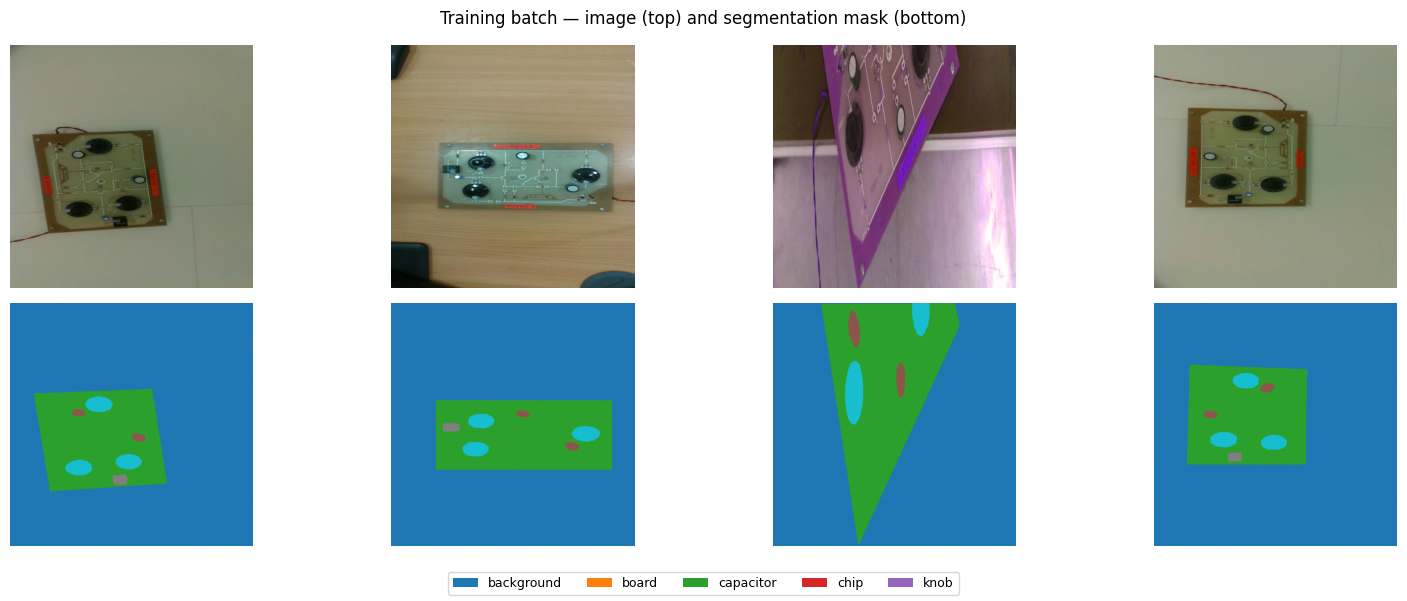

Class indices present in this batch: [0, 1, 2, 3, 4]
Expected: 0=background {1: 'board', 2: 'capacitor', 3: 'chip', 4: 'knob'}


In [5]:
imgs, masks = next(iter(train_loader))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

n = min(4, BATCH_SIZE)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 6))

for i in range(n):
    img_show = (imgs[i] * std + mean).permute(1, 2, 0).numpy().clip(0, 1)
    axes[0, i].imshow(img_show)
    axes[0, i].axis('off')
    axes[1, i].imshow(masks[i].numpy(), cmap='tab10', vmin=0, vmax=NUM_CLASSES)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Image',  fontsize=11)
axes[1, 0].set_ylabel('Mask',   fontsize=11)

# Legend
from matplotlib.patches import Patch
import matplotlib.cm as cm
tab10 = cm.get_cmap('tab10')
legend_items = [Patch(facecolor=tab10(0), label='background')]
for i, cls in enumerate(CLASSES):
    legend_items.append(Patch(facecolor=tab10(i + 1), label=cls))
fig.legend(handles=legend_items, loc='lower center', ncol=5, fontsize=9)

plt.suptitle('Training batch — image (top) and segmentation mask (bottom)')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

unique_classes = masks.unique().tolist()
print('Class indices present in this batch:', unique_classes)
print('Expected: 0=background', {i+1: c for i, c in enumerate(CLASSES)})

In [6]:
# This is the real check — not the colours
imgs, masks = next(iter(train_loader))
print('Class indices present in this batch:', masks.unique().tolist())
print('Expected: 0=bg, 1=board, 2=capacitor, 3=chip, 4=knob')

# Check a specific image — does board cover the whole image or just part?
for i in range(len(masks)):
    unique = masks[i].unique().tolist()
    print(f'  Image {i}: classes present = {unique}')

Class indices present in this batch: [0, 1, 2, 3, 4]
Expected: 0=bg, 1=board, 2=capacitor, 3=chip, 4=knob
  Image 0: classes present = [0, 1, 2, 3, 4]
  Image 1: classes present = [0, 1, 2, 3, 4]
  Image 2: classes present = [0, 1, 2, 3, 4]
  Image 3: classes present = [0, 1, 2, 3, 4]


## 7. Build U-Net model

In [7]:
model = smp.Unet(
    encoder_name    = 'resnet34',        # **diff encoder 
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = NUM_CLASSES + 1,   # +1 for background class
    activation      = None,              # raw logits; loss applies softmax internally
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params / 1e6:.1f} M')

Trainable parameters: 24.4 M


## 8. Loss function, optimiser, scheduler

In [8]:
# Dice + CrossEntropy combined — handles class imbalance well for small datasets
dice_loss = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
ce_loss   = nn.CrossEntropyLoss()

def combined_loss(preds, targets):
    return 0.5 * dice_loss(preds, targets) + 0.5 * ce_loss(preds, targets)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

print('Loss, optimizer, and scheduler ready.')

Loss, optimizer, and scheduler ready.


## 9. Training loop

In [9]:
EPOCHS    = 80
SAVE_PATH = Path('unet_best.pth')

def iou_score(preds, targets, num_classes):
    """Mean IoU across foreground classes (skips background)."""
    preds = preds.argmax(dim=1)
    ious  = []
    for c in range(1, num_classes + 1):
        pred_c   = (preds == c)
        target_c = (targets == c)
        inter = (pred_c & target_c).sum().float()
        union = (pred_c | target_c).sum().float()
        if union > 0:
            ious.append((inter / union).item())
    return np.mean(ious) if ious else 0.0

history  = {'train_loss': [], 'val_loss': [], 'val_iou': []}
best_iou = 0.0

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    train_losses = []
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_losses, val_ious = [], []
    with torch.no_grad():
        for imgs, masks in valid_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            val_losses.append(combined_loss(preds, masks).item())
            val_ious.append(iou_score(preds.cpu(), masks.cpu(), NUM_CLASSES))

    scheduler.step()

    t_loss = np.mean(train_losses)
    v_loss = np.mean(val_losses)
    v_iou  = np.mean(val_ious)
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_iou'].append(v_iou)

    if v_iou > best_iou:
        best_iou = v_iou
        torch.save(model.state_dict(), SAVE_PATH)
        saved = '[BEST — saved]'
    else:
        saved = ''

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'train_loss: {t_loss:.4f}  '
              f'val_loss: {v_loss:.4f}  '
              f'val_IoU: {v_iou:.4f}  {saved}')

print(f'\nDone. Best val IoU: {best_iou:.4f}  Weights saved to: {SAVE_PATH}')

Epoch   1/80  train_loss: 0.9944  val_loss: 0.7358  val_IoU: 0.3032  [BEST — saved]
Epoch  10/80  train_loss: 0.2057  val_loss: 0.1838  val_IoU: 0.8987  
Epoch  20/80  train_loss: 0.0650  val_loss: 0.0628  val_IoU: 0.9201  
Epoch  30/80  train_loss: 0.0381  val_loss: 0.0411  val_IoU: 0.9377  [BEST — saved]
Epoch  40/80  train_loss: 0.0327  val_loss: 0.0361  val_IoU: 0.9397  
Epoch  50/80  train_loss: 0.0297  val_loss: 0.0353  val_IoU: 0.9407  [BEST — saved]
Epoch  60/80  train_loss: 0.0304  val_loss: 0.0351  val_IoU: 0.9387  
Epoch  70/80  train_loss: 0.0500  val_loss: 0.0339  val_IoU: 0.9381  
Epoch  80/80  train_loss: 0.0236  val_loss: 0.0294  val_IoU: 0.9400  

Done. Best val IoU: 0.9423  Weights saved to: unet_best.pth


## 10. Training curves

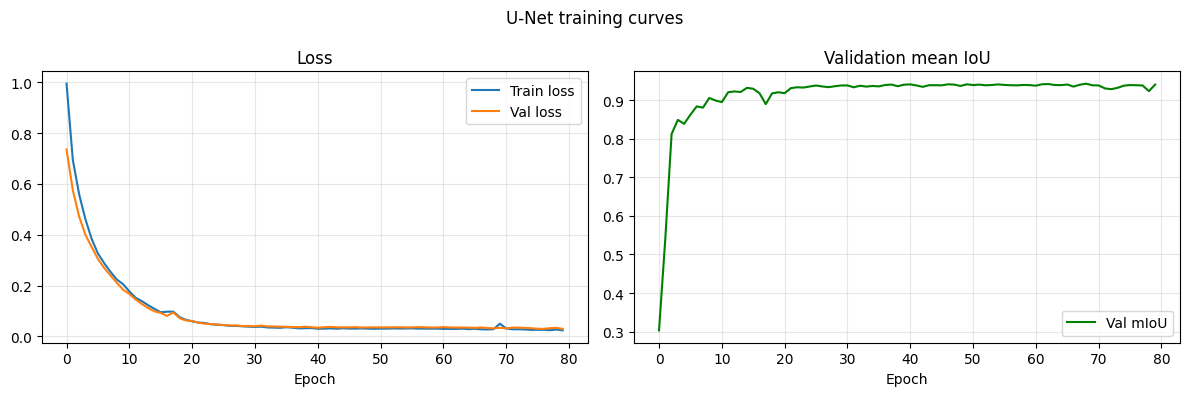

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'],   label='Val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_iou'], color='green', label='Val mIoU')
axes[1].set_title('Validation mean IoU')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('U-Net training curves')
plt.tight_layout()
plt.show()

## 11. Test set inference and visualisation

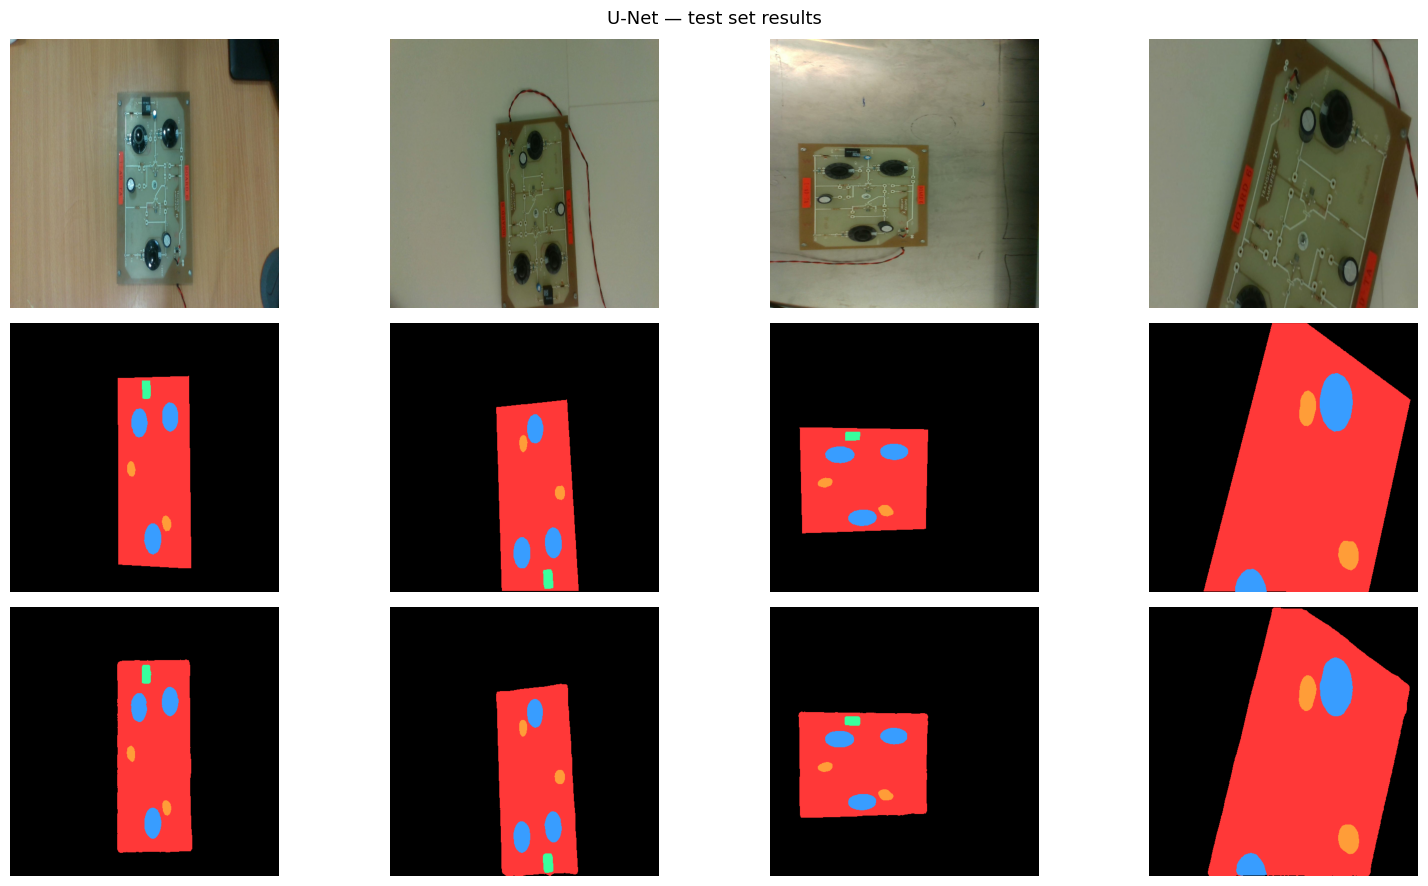

In [11]:
# Load best weights
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

# Colour palette: background + one colour per class
PALETTE = np.array([
    [  0,   0,   0],   # 0 background
    [255,  56,  56],   # 1 board
    [255, 157,  56],   # 2 capacitor
    [ 56, 255, 157],   # 3 chip
    [ 56, 157, 255],   # 4 knob
], dtype=np.uint8)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

n_show = min(4, len(test_ds))
fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 9))

test_iter = iter(test_loader)
for col in range(n_show):
    imgs, masks = next(test_iter)
    imgs, masks = imgs.to(device), masks.to(device)

    with torch.no_grad():
        pred_mask = model(imgs).argmax(dim=1).squeeze().cpu().numpy()

    img_show  = (imgs[0].cpu() * std + mean).permute(1, 2, 0).numpy().clip(0, 1)
    gt_mask   = masks[0].cpu().numpy()
    pred_color = PALETTE[pred_mask]
    gt_color   = PALETTE[gt_mask]

    axes[0, col].imshow(img_show);    axes[0, col].axis('off')
    axes[1, col].imshow(gt_color);    axes[1, col].axis('off')
    axes[2, col].imshow(pred_color);  axes[2, col].axis('off')

axes[0, 0].set_ylabel('Image',         fontsize=10)
axes[1, 0].set_ylabel('Ground truth',  fontsize=10)
axes[2, 0].set_ylabel('Prediction',    fontsize=10)

plt.suptitle('U-Net — test set results', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Per-class IoU on test set

In [12]:
per_class_inter = np.zeros(NUM_CLASSES + 1)
per_class_union = np.zeros(NUM_CLASSES + 1)

model.eval()
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs  = imgs.to(device)
        preds = model(imgs).argmax(dim=1).squeeze().cpu().numpy()
        gt    = masks.squeeze().numpy()

        for c in range(1, NUM_CLASSES + 1):
            pred_c   = (preds == c)
            target_c = (gt    == c)
            per_class_inter[c] += (pred_c & target_c).sum()
            per_class_union[c] += (pred_c | target_c).sum()

print('Per-class IoU on test set:')
ious = []
for c, cls_name in enumerate(CLASSES, start=1):
    if per_class_union[c] > 0:
        iou = per_class_inter[c] / per_class_union[c]
        ious.append(iou)
        print(f'  {cls_name:12s}: {iou:.4f}')
    else:
        print(f'  {cls_name:12s}: N/A (not present in test set)')

print(f'\n  Mean IoU      : {np.mean(ious):.4f}')

Per-class IoU on test set:
  board       : 0.9690
  capacitor   : 0.9391
  chip        : 0.9291
  knob        : 0.9571

  Mean IoU      : 0.9486


In [ ]:
- encoder 
- unet++
- dice coeff (test accuracy)
- search for image size input (high resolution into smaller model input size; not 512)